# Self-Refinement Evaluation
This notebook presents an analysis of results from a self-refinement pipeline applied to a sample of reasoning and non-reasoning models. We examine accuracy gains across model–dataset pairs, considering model type, hint token length, and key themes extracted from hint sentences.

In [1]:
# Import libraries
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from src.plot_utils import plot_by_dataset, plot_aggregated_metric_by_dataset, plot_model_category_comparison, plot_metric_heatmap, plot_outcome_by_model_category_barchart, plot_tokens_barchart, plot_token_stage_barchart, plot_hintlen_vs_accuracy_gain, plot_hint_correction_sankey

In [2]:
# Load data
import os
os.makedirs("eval_results/figs", exist_ok=True)
metrics = pd.read_csv("eval_results/metrics.csv")
per_question_tokens = pd.read_csv("eval_results/per_question_tokens.csv")
top_keywords = pd.read_csv("eval_results/top_keywords_paraphrase_MiniLM_L3_v2.csv")

In [3]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


## Total Corrections amount

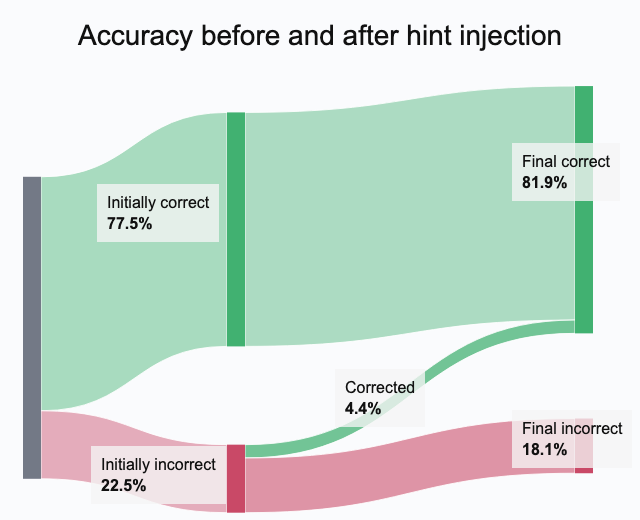

In [4]:
from IPython.display import Image, display

fig = plot_hint_correction_sankey(metrics)
fig.write_image("eval_results/figs/hint_correction_sankey.pdf")
fig.write_image("eval_results/figs/hint_correction_sankey.png")
display(Image("eval_results/figs/hint_correction_sankey.png"))

## I. Analysis of Aggregated Performance Metrics

Metrics are aggregated by model, dataset, and model category (mean accuracy and correction rates; sums of counts). The section then visualizes accuracy gain (Δ accuracy) after hint-based correction by model and dataset, and compares model categories across initial accuracy, post-hint accuracy, and correction rate.

In [5]:
aggregated_metrics = (
    metrics
    .groupby(['model', 'dataset', 'model_category'])
    .agg({
        'initial_accuracy': 'mean',
        'post_hint_accuracy': 'mean',
        'delta_accuracy': 'mean',
        'n_incorrect_initial': 'sum',
        'n_corrected': 'sum',
        'correction_rate': 'mean'
    })
    .reset_index()
)

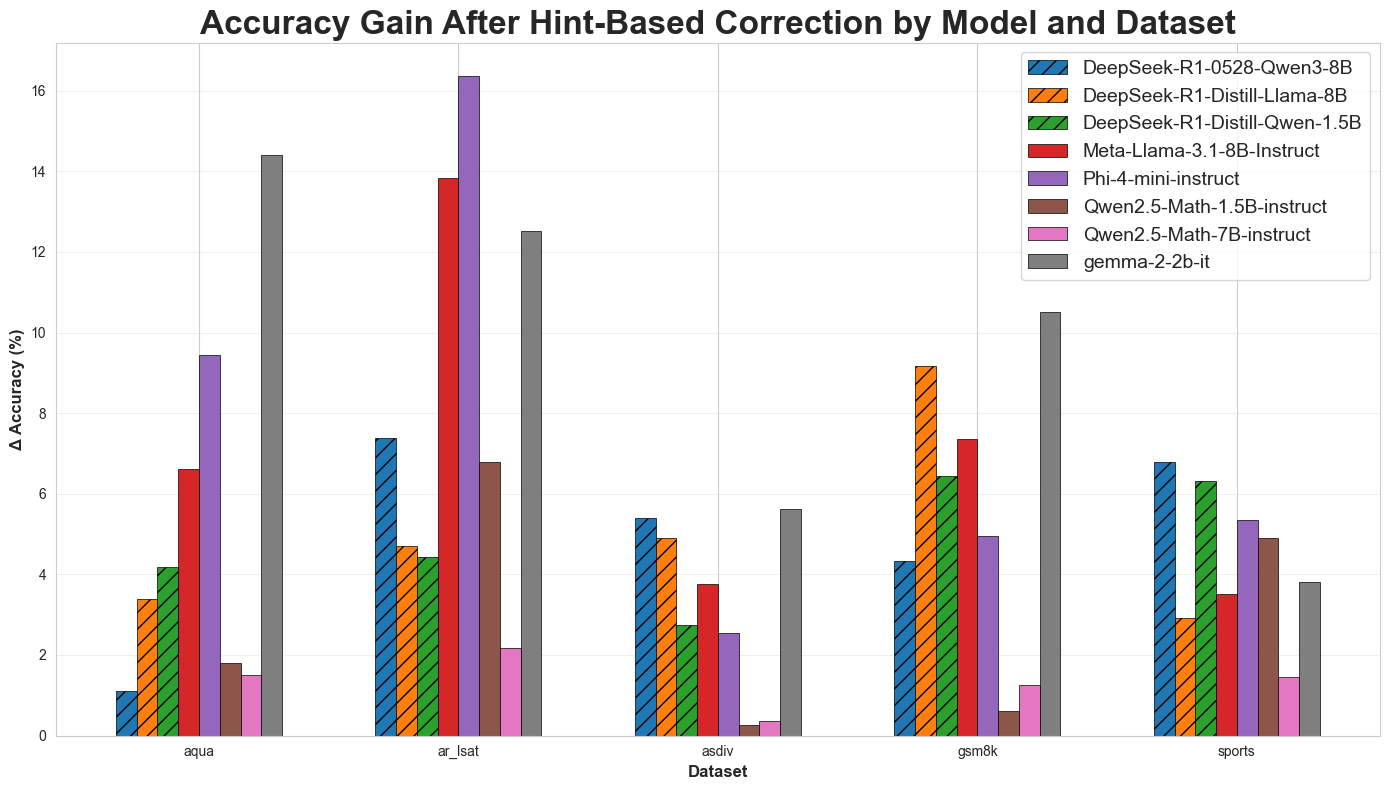

In [6]:
plot_aggregated_metric_by_dataset(
    aggregated_metrics,
    metric_col='delta_accuracy',
    ylabel='Δ Accuracy (%)',
    title=('Accuracy Gain After Hint-Based Correction by Model and Dataset'),
    save_path='eval_results/figs/aggregated_delta_accuracy_by_dataset.pdf'
)


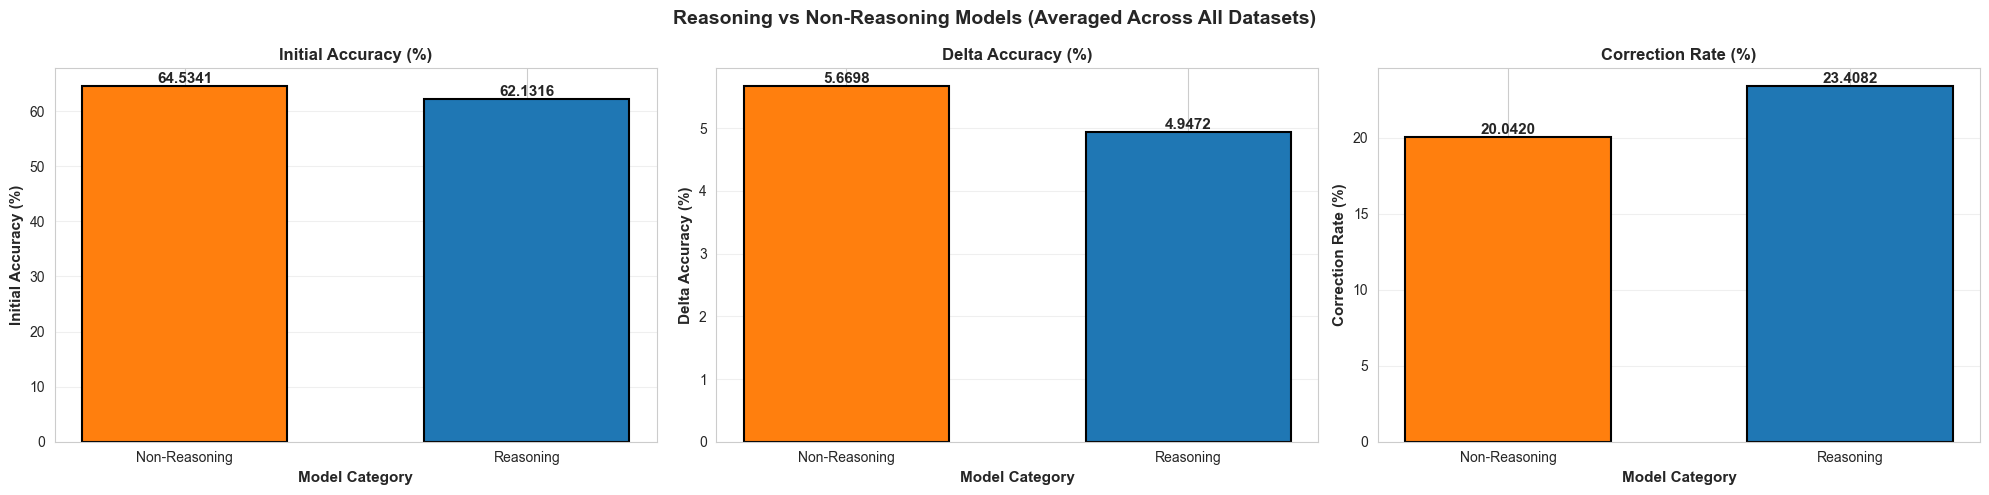

In [7]:
plot_model_category_comparison(aggregated_metrics, save_path='eval_results/figs/model_category_comparison.pdf')

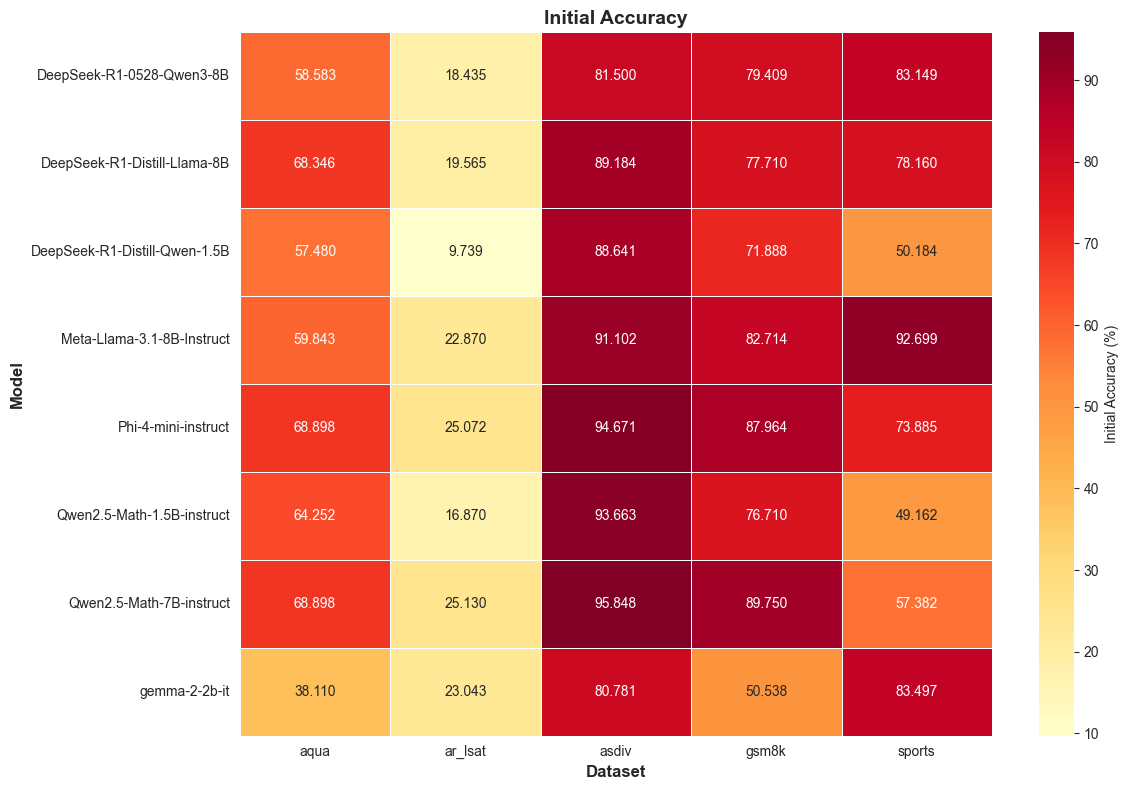

In [8]:
plot_metric_heatmap(
    aggregated_metrics,
    value_col="initial_accuracy",
    title="Initial Accuracy",
    cmap="YlOrRd",
    fmt=".3f",
    save_path='eval_results/figs/heatmap_initial_accuracy.pdf',
    cbar_label="Initial Accuracy (%)"
)


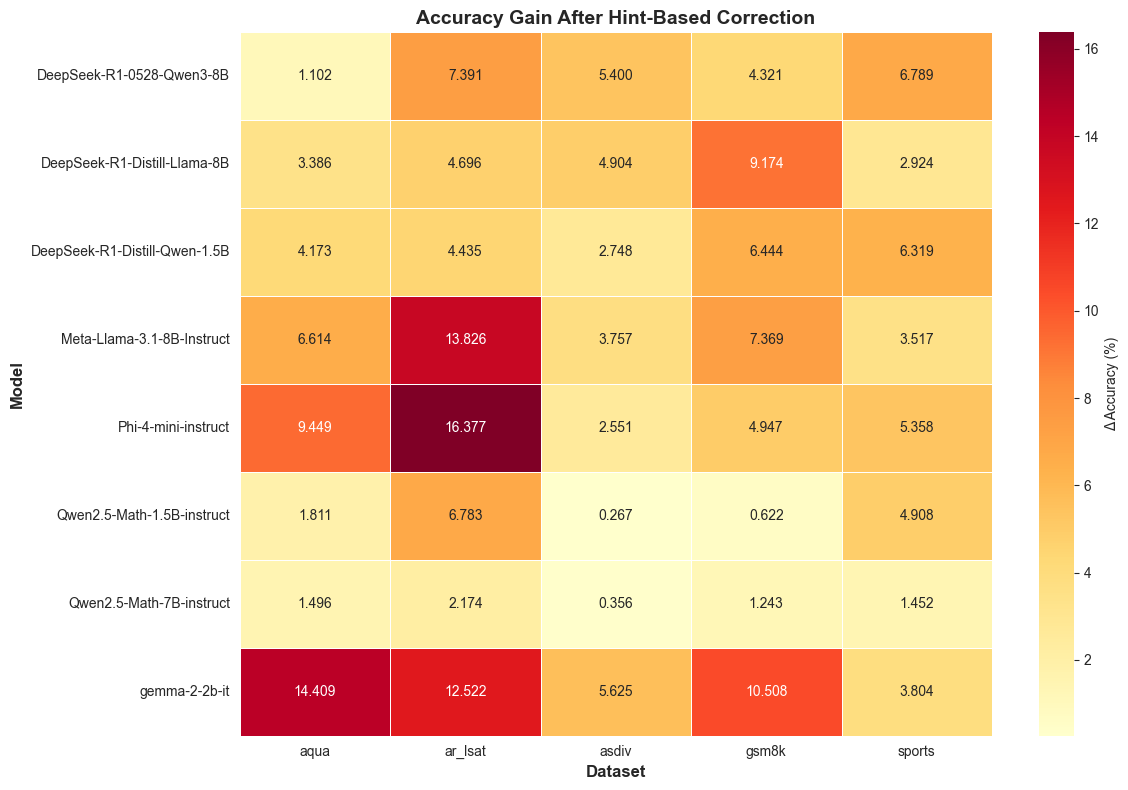

In [9]:
plot_metric_heatmap(
    aggregated_metrics,
    value_col="delta_accuracy",
    title="Accuracy Gain After Hint-Based Correction",
    cmap="YlOrRd",
    fmt=".3f",
    save_path='eval_results/figs/heatmap_delta_accuracy.pdf',
    cbar_label="Δ Accuracy (%)"
)

## II. Generated Tokens Number

This section analyzes hint and inference token counts: average hint length by model category and outcome, by model, by dataset, and by correction outcome; a token-stage breakdown for initially incorrect questions; and the correlation between hint length and accuracy gain.

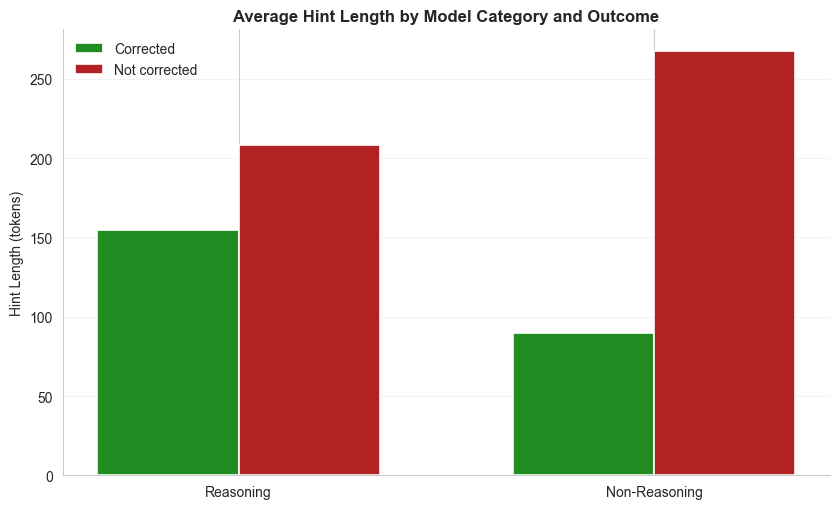

In [10]:
plot_outcome_by_model_category_barchart(
    per_question_tokens,
    value_col="hint_tokens",
    title="Average Hint Length by Model Category and Outcome",
    ylabel="Hint Length (tokens)",
    agg="mean",
    save_path='eval_results/figs/hint_length_by_model_category_outcome.pdf'
)


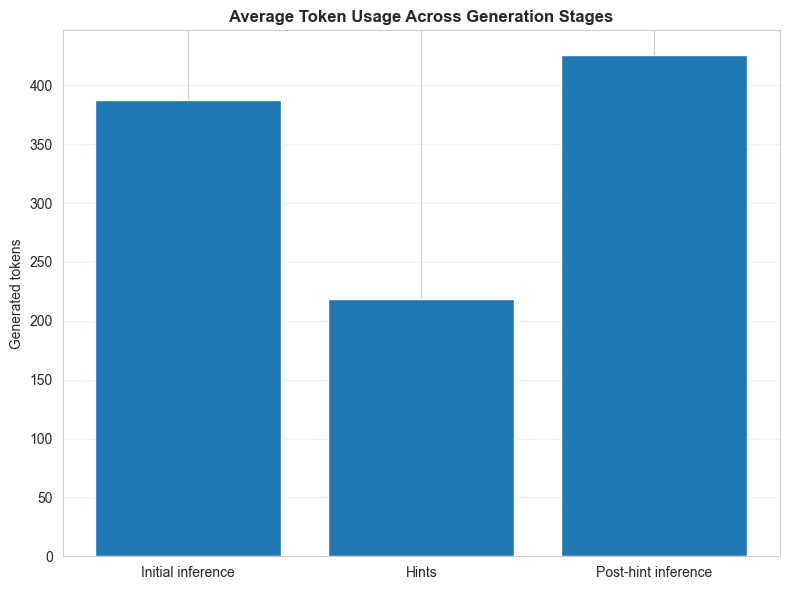

In [11]:
plot_token_stage_barchart(per_question_tokens[
    (per_question_tokens['initial_correct'] == 0) &
    (per_question_tokens['hint_tokens'].notnull())
], save_path='eval_results/figs/token_stage_barchart.pdf')

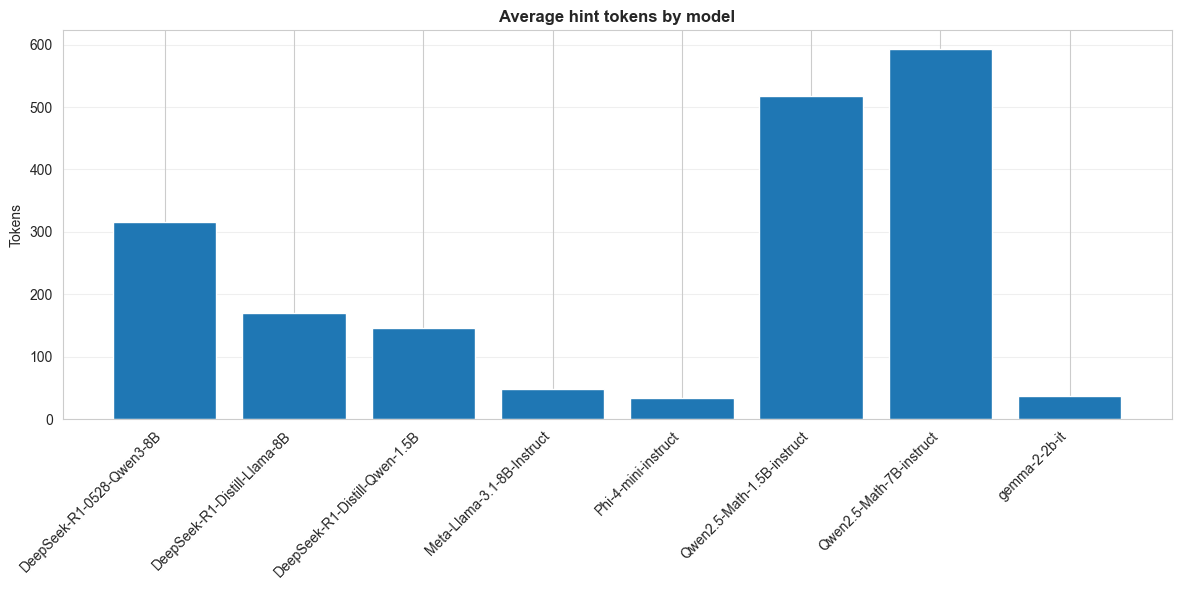

In [12]:
plot_tokens_barchart(
    per_question_tokens,
    "hint_tokens",
    "model",
    title="Average hint tokens by model",
    save_path='eval_results/figs/tokens_barchart_by_model.pdf'
)


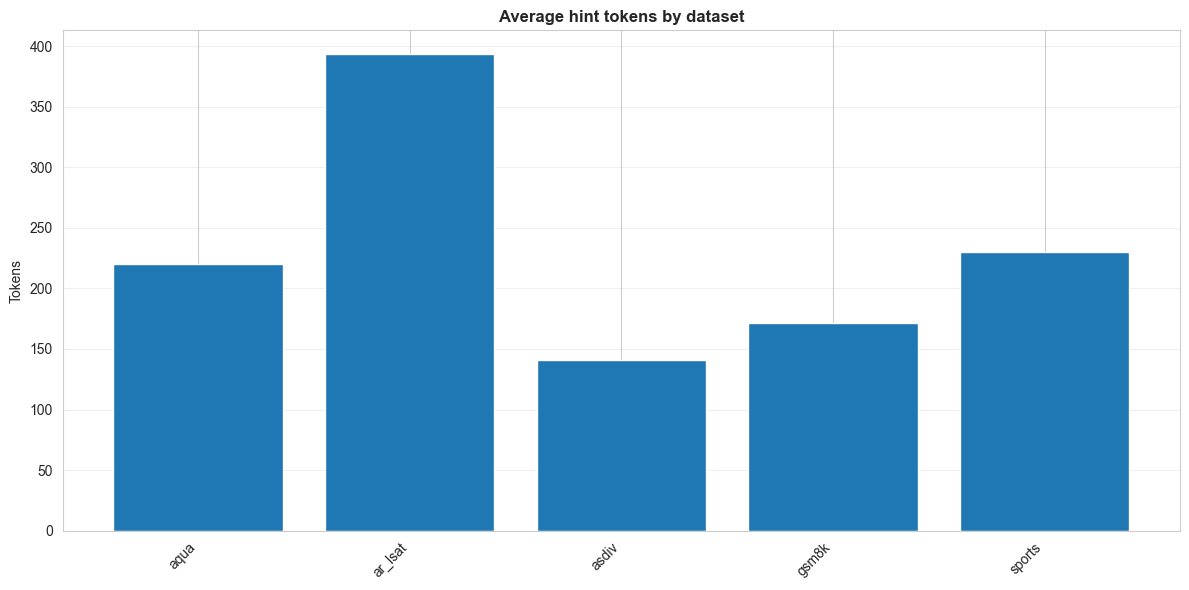

In [13]:
plot_tokens_barchart(
    per_question_tokens,
    "hint_tokens",
    "dataset",
    title="Average hint tokens by dataset",
    save_path='eval_results/figs/tokens_barchart_by_dataset.pdf'
)

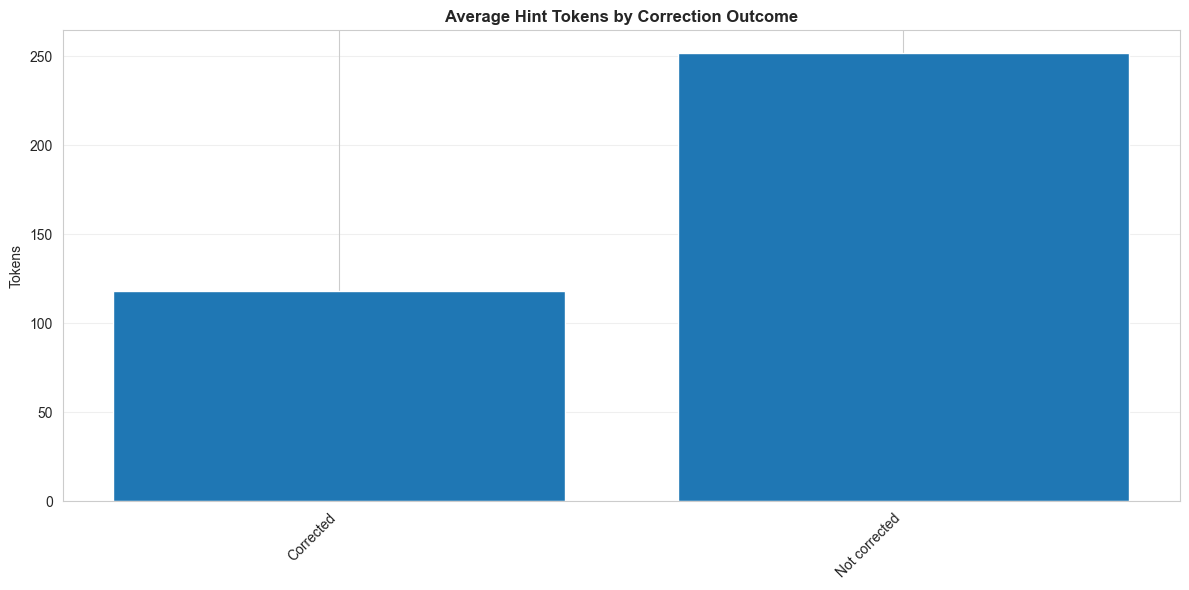

In [14]:
plot_tokens_barchart(per_question_tokens, "hint_tokens", "hint_outcome", title="Average Hint Tokens by Correction Outcome", save_path='eval_results/figs/tokens_barchart_by_correction_outcome.pdf')

In [15]:
aggregated_hint_outcomes = (
    per_question_tokens
    .groupby(['model', 'dataset', 'model_category', 'hint_outcome'])
    .agg({
        'hint_tokens': 'mean',
        'initial_inference_tokens': 'mean',
        'post_hint_inference_tokens': 'mean',

    })
    .reset_index()
)

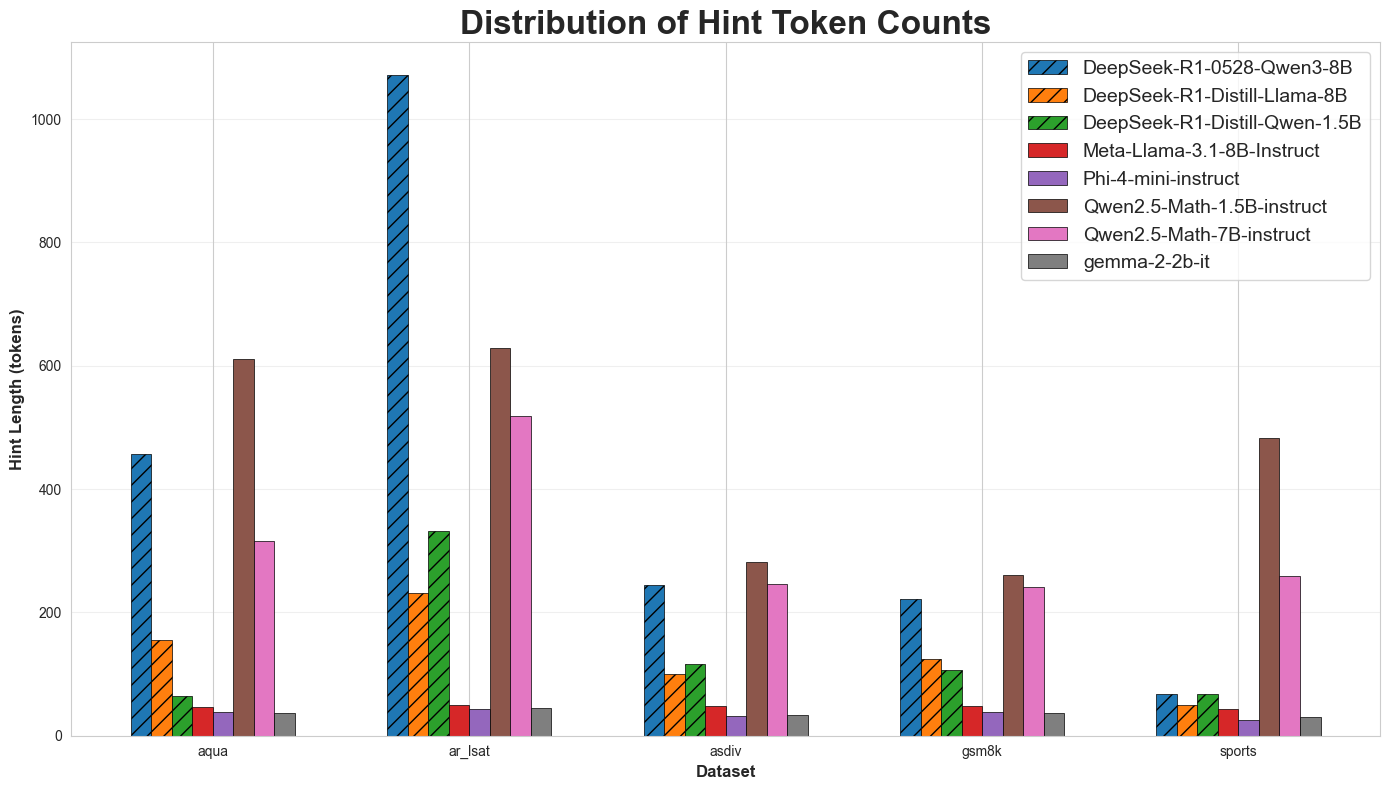

In [16]:
plot_aggregated_metric_by_dataset(
    aggregated_hint_outcomes,
    metric_col='hint_tokens',
    ylabel='Hint Length (tokens)',
    title='Distribution of Hint Token Counts',
    save_path='eval_results/figs/aggregated_hint_tokens_by_dataset.pdf'
)



In [17]:
# --- average hint length per model (across all datasets) ---
avg_hint_len = (
    per_question_tokens
    .groupby(["model", "model_category"], as_index=False)["hint_tokens"]
    .mean()
    .rename(columns={"hint_tokens": "avg_hint_tokens"})
)

# --- aggregate metrics by model (across all datasets) ---
metrics_by_model = (
    aggregated_metrics
    .groupby(["model", "model_category"])
    .agg({
        "initial_accuracy": "mean",
        "post_hint_accuracy": "mean",
        "delta_accuracy": "mean",
        "n_incorrect_initial": "sum",
        "n_corrected": "sum",
        "correction_rate": "mean"
    })
    .reset_index()
)

merged_df = metrics_by_model.merge(
    avg_hint_len,
    on=["model", "model_category"],
    how="left"
)


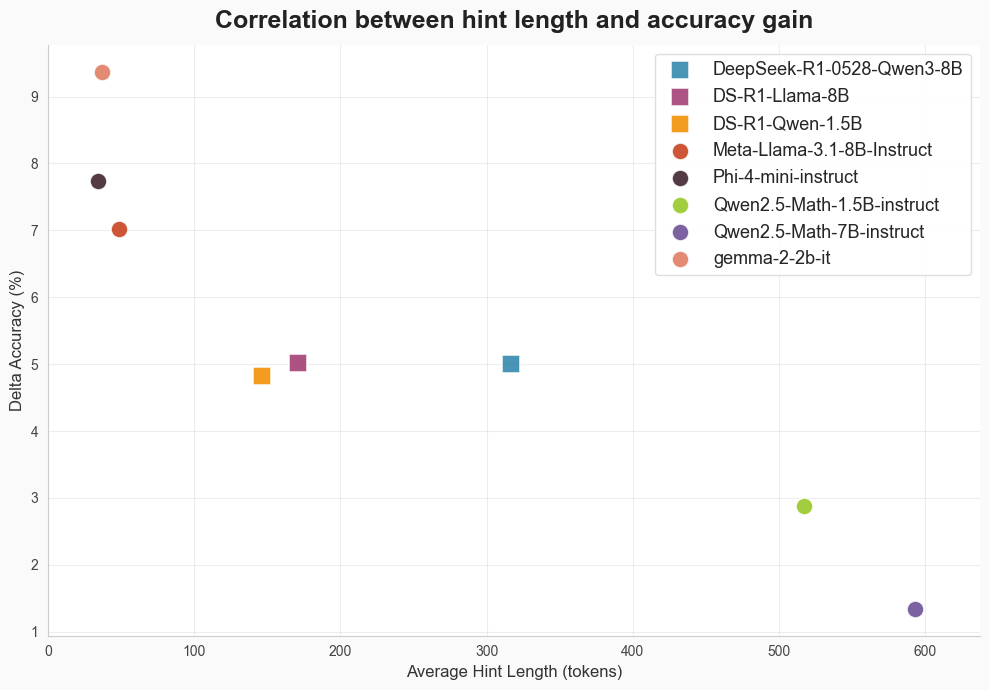

In [18]:
plot_hintlen_vs_accuracy_gain(
    merged_df,
    title="Correlation between hint length and accuracy gain",
    fontsize=13,
    save_path='eval_results/figs/hint_length_vs_accuracy_gain.pdf'
)


## III. Effect of Maximum Token Budget
This section analyzes how increasing the maximum number of tokens affects model performance across different datasets.

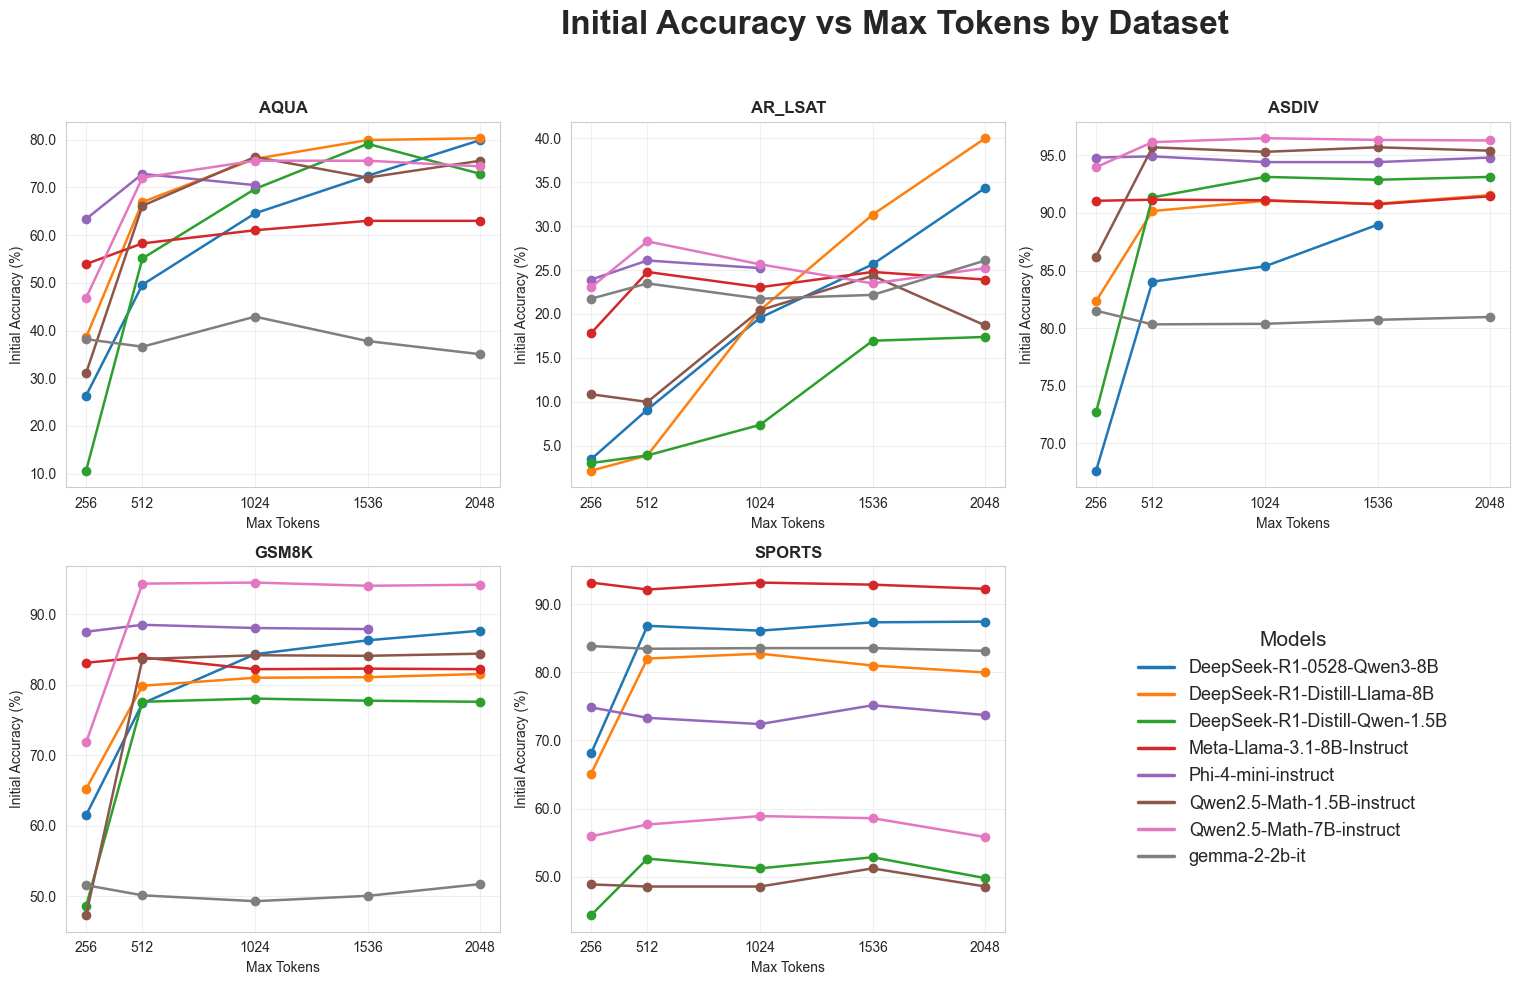

In [19]:
# Initial Accuracy
plot_by_dataset(
    metrics, "initial_accuracy", "Initial Accuracy (%)",
    "Initial Accuracy vs Max Tokens by Dataset",
    save_path='eval_results/figs/initial_accuracy_by_dataset.pdf'
    #share_y=True
)

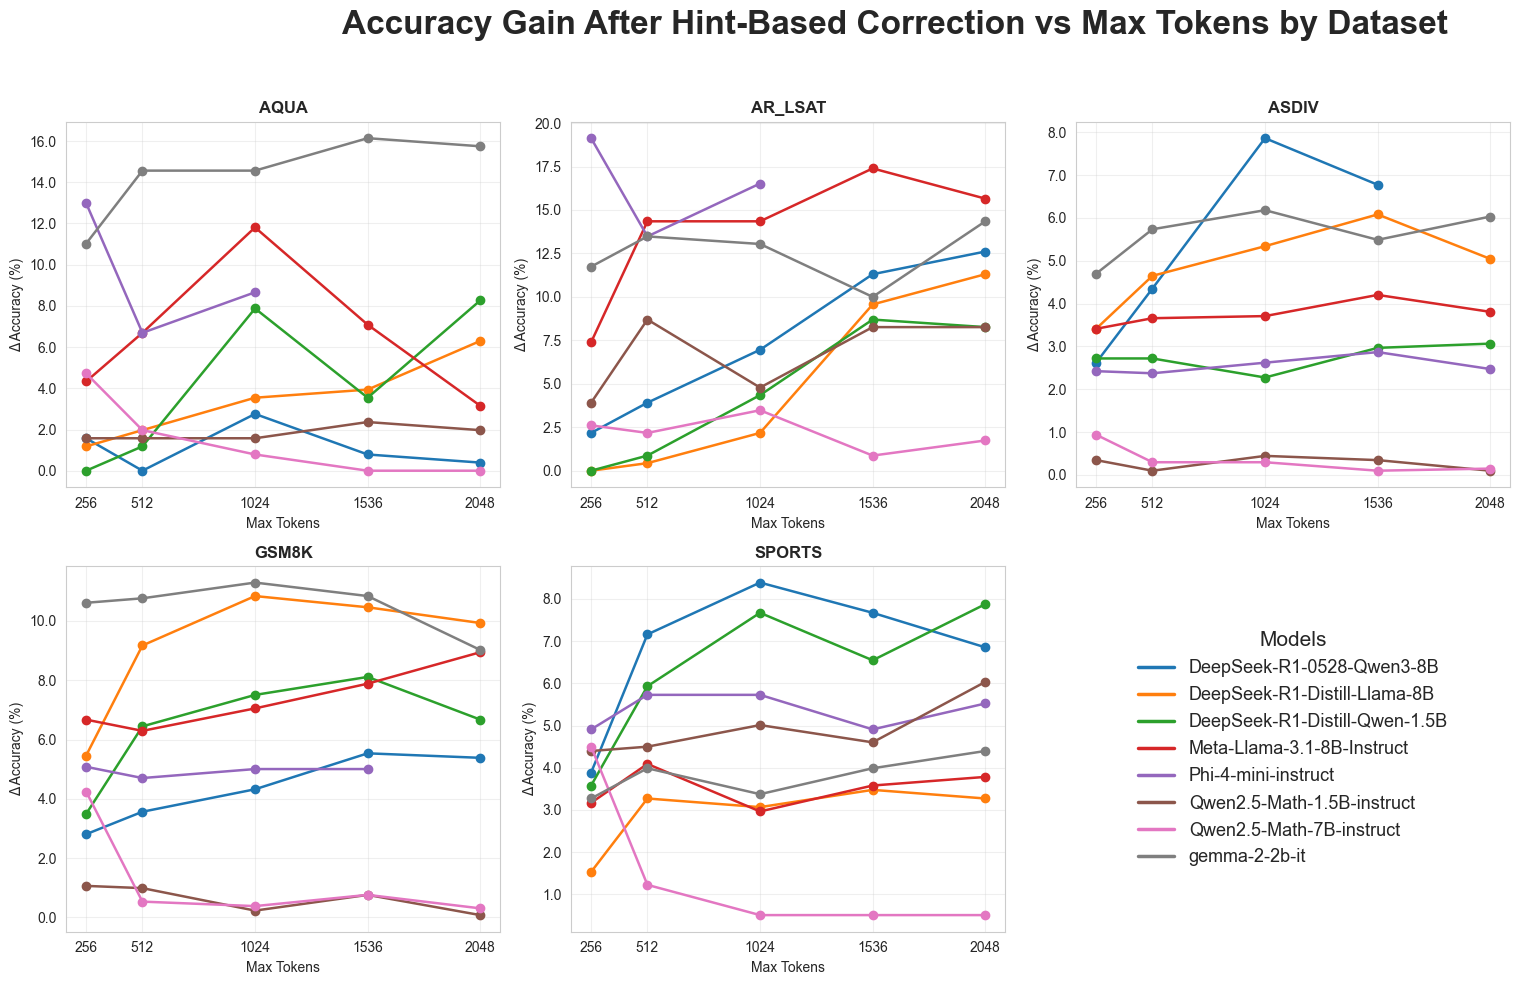

In [20]:
# Improvement in accuracy after applying hints (post-hint − initial)
plot_by_dataset(
    metrics, "delta_accuracy", "Δ Accuracy (%)",
    "Accuracy Gain After Hint-Based Correction vs Max Tokens by Dataset",
    save_path='eval_results/figs/accuracy_gain_by_dataset.pdf'
    #share_y=True
)

## IV. Hint topic

This section collects all hint sentences from every model/dataset pair and runs **KeyNMF** (NMF-based topic model with contextually sensitive embeddings for keyword retrieval and term importance). It then visualizes the discovered topics and their distribution.

In [21]:
# Parse top_keywords and build counts per (keyword, outcome)
top_kw = top_keywords.copy()
top_kw["keywords_list"] = top_kw["top5_keywords"].apply(ast.literal_eval)
top_kw["outcome"] = top_kw["is_correct"].map({True: "Correct", False: "Incorrect"})

def flatten_keywords(df, keep_cols=None):
    """Flatten keywords_list into one row per keyword. keep_cols: optional list (e.g. ['model'] or ['dataset']) to keep in each row."""
    keep_cols = keep_cols or []
    rows = []
    for _, row in df.iterrows():
        base = {c: row[c] for c in keep_cols if c in df.columns}
        for kw in row["keywords_list"]:
            rows.append({**base, "keyword": kw, "outcome": row["outcome"], "n_hints": row["n_hints"]})
    return pd.DataFrame(rows)

# 1) Top words per hint outcome (count = # of model×dataset buckets where keyword was in top5)
kw_flat = flatten_keywords(top_kw)
kw_counts = kw_flat.groupby(["keyword", "outcome"], as_index=False).agg(
    total_n_hints=("n_hints", "sum"), count=("n_hints", "count")
)
top_n = 10
print("1) Top words per hint outcome (by total_n_hints)")
for outcome in ["Correct", "Incorrect"]:
    sub = kw_counts[kw_counts["outcome"] == outcome].nlargest(top_n, "total_n_hints")
    print(f"\n--- {outcome} ---")
    display(sub[["keyword",  "count"]].reset_index(drop=True))

1) Top words per hint outcome (by total_n_hints)

--- Correct ---


,keyword,count
0,total cost,5
1,total distance,4
2,calculate total,3
3,number students,3
4,cost,3
5,number days,2
6,dividing total,3
7,cookies,3
8,distance traveled,3
9,dividing,2



--- Incorrect ---


,keyword,count
0,total cost,5
1,hockey player,6
2,number students,4
3,basketball,5
4,calculate total,4
5,distance traveled,3
6,total distance,4
7,model reasoning,6
8,football,2
9,answer boxed,5


In [22]:
# Same aggregation but by model (not by Correct/Incorrect)
kw_flat_model = flatten_keywords(top_kw, keep_cols=["model"])
kw_counts_model = kw_flat_model.groupby(["model", "keyword"], as_index=False).agg(
    total_n_hints=("n_hints", "sum"), count=("n_hints", "count")
)
top_n = 10
print("Top words per model (by total_n_hints)")
for model in sorted(kw_counts_model["model"].unique()):
    sub = kw_counts_model[kw_counts_model["model"] == model].nlargest(top_n, "total_n_hints")
    print(f"\n--- {model} ---")
    display(sub[["keyword", "count"]].reset_index(drop=True))

Top words per model (by total_n_hints)

--- DeepSeek-R1-0528-Qwen3-8B ---


,keyword,count
0,model reasoning,5
1,box cookies,2
2,boxes total,2
3,cookies,2
4,total cookies,2
5,reasoning model,4
6,baseball player,2
7,basketball player,2
8,hockey player,2
9,ice hockey,2



--- DeepSeek-R1-Distill-Llama-8B ---


,keyword,count
0,cost,2
1,total cost,2
2,basketball,2
3,basketball player,2
4,hockey player,2
5,dividing,2
6,dividing total,2
7,football quarterback,1
8,professional basketball,1
9,number days,1



--- DeepSeek-R1-Distill-Qwen-1.5B ---


...

,keyword,count
0,answer boxed,6
1,model reasoning,6
2,final answer,5
3,model predicted,2
4,predicted answer,1
5,boxed,4
6,helpful assistant,5
7,assistant,4
8,boxed msk,3
9,french novels,2



--- Qwen2.5-Math-7B-instruct ---


,keyword,count
0,basketball,1
1,basketball action,1
2,determine sentence,1
3,plausibility sentence,1
4,shot basketball,1
5,help model,3
6,answer boxed,2
7,model,2
8,batch cookies,1
9,bay holding,1



--- gemma-2-2b-it ---


,keyword,count
0,number students,3
1,distance traveled,4
2,calculate total,2
3,total cost,2
4,total distance,2
5,number divides,2
6,number pencils,1
7,smallest number,1
8,total number,1
9,basketball,2


In [23]:
# Same aggregation but by dataset only (not by Correct/Incorrect)
kw_flat_dataset = flatten_keywords(top_kw, keep_cols=["dataset"])
kw_counts_dataset = kw_flat_dataset.groupby(["dataset", "keyword"], as_index=False).agg(
    total_n_hints=("n_hints", "sum"), count=("n_hints", "count")
)
top_n = 10
print("Top words per dataset (by total_n_hints)")
for dataset in sorted(kw_counts_dataset["dataset"].unique()):
    sub = kw_counts_dataset[kw_counts_dataset["dataset"] == dataset].nlargest(top_n, "total_n_hints")
    print(f"\n--- {dataset} ---")
    display(sub[["keyword",  "count"]].reset_index(drop=True))

Top words per dataset (by total_n_hints)

--- aqua ---


,keyword,count
0,probability,4
1,distance traveled,3
2,distance,3
3,perimeter,3
4,consider probability,1
5,selling price,2
6,codes,3
7,price consider,1
8,profit percentage,1
9,average speed,2



--- ar_lsat ---


,keyword,count
0,order articles,2
1,order solos,2
2,french novels,4
3,solos,2
4,order lectures,1
5,recorded auditions,1
6,constraint,2
7,constraints,2
8,russian novels,3
9,condition,1



--- asdiv ---


,keyword,count
0,number students,5
1,dividing,5
2,total number,3
3,dividing total,5
4,number divides,2
5,smallest number,2
6,number pencils,2
7,model reasoning,4
8,number teams,2
9,number cookies,2



--- gsm8k ---


,keyword,count
0,total cost,10
1,total distance,7
2,calculate total,6
3,distance traveled,3
4,number students,2
5,cost,4
6,total time,3
7,calculate,2
8,calculating total,2
9,model reasoning,3



--- sports ---


,keyword,count
0,hockey player,10
1,basketball,7
2,football,4
3,football quarterback,3
4,ice hockey,7
5,basketball player,8
6,football player,3
7,quarterback,2
8,answer boxed,2
9,final answer,2
